In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/MyDrive/Colab Notebooks/Ml_Project_Luminar/american_bankruptcy.csv'
df=pd.read_csv(path)
print(f"Dataset Loaded Successfully! Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully! Shape: 78,682 rows, 21 columns


In [116]:
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [117]:
#Check for missing / null values
print("Total missing values in dataset:", df.isnull().sum().sum())

#Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

#Check year coverage for the chronological split
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

#Check number of unique companies
print(f"Number of unique companies: {df['company_name'].nunique()}")

Total missing values in dataset: 0
Duplicate rows: 0
Year range: 1999 to 2018
Number of unique companies: 8971


In [118]:
df['status_label'].value_counts()

,count
status_label,
alive,73462
failed,5220


In [119]:
df['year'].value_counts()

,count
year,
1999,5308
2000,5226
2001,4897
2002,4651
2003,4417
2004,4348
2005,4205
2006,4128
2007,4009


In [120]:
# Feature mapping dictionary based on the research paper
feature_map = {
    'X1': 'Current_Assets',
    'X2': 'COGS',
    'X3': 'Depreciation_Amortization',
    'X4': 'EBITDA',
    'X5': 'Inventory',
    'X6': 'Net_Income',
    'X7': 'Total_Receivables',
    'X8': 'Market_Value',
    'X9': 'Net_Sales',
    'X10': 'Total_Assets',
    'X11': 'Total_Long_Term_Debt',
    'X12': 'EBIT',
    'X13': 'Gross_Profit',
    'X14': 'Total_Current_Liabilities',
    'X15': 'Retained_Earnings',
    'X16': 'Total_Revenue',
    'X17': 'Total_Liabilities',
    'X18': 'Total_Operating_Expenses'
}
df.rename(columns=feature_map,inplace=True)

In [121]:
df['target']=df['status_label'].map({'alive':0,'failed':1})
print(f"\nTarget distribution (0: Alive, 1: Failed):")
print(df['target'].value_counts())
print(f"\nMinority class percentage: {df['target'].mean() * 100:.2f}%")


Target distribution (0: Alive, 1: Failed):
target
0    73462
1     5220
Name: count, dtype: int64

Minority class percentage: 6.63%


In [122]:
#Updated columns
print("\nUpdated column names:")
print(df.columns.tolist())


Updated column names:
['company_name', 'status_label', 'year', 'Current_Assets', 'COGS', 'Depreciation_Amortization', 'EBITDA', 'Inventory', 'Net_Income', 'Total_Receivables', 'Market_Value', 'Net_Sales', 'Total_Assets', 'Total_Long_Term_Debt', 'EBIT', 'Gross_Profit', 'Total_Current_Liabilities', 'Retained_Earnings', 'Total_Revenue', 'Total_Liabilities', 'Total_Operating_Expenses', 'target']


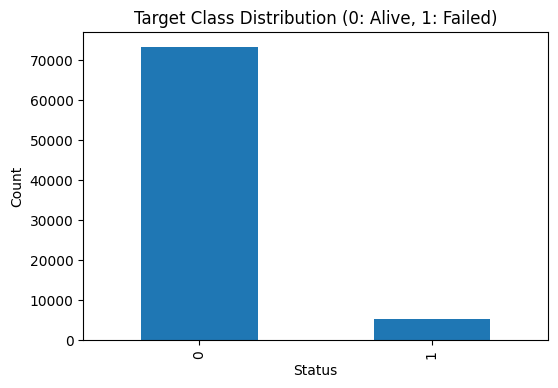

In [123]:
# Class Imbalance Plot
plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar')
plt.title('Target Class Distribution (0: Alive, 1: Failed)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

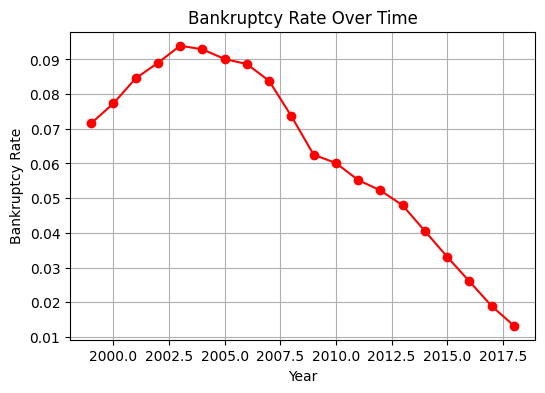

In [124]:
yearly_rates=df.groupby('year')['target'].mean()
plt.figure(figsize=(6,4))
yearly_rates.plot(kind='line',marker='o', color='red')
plt.title('Bankruptcy Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Bankruptcy Rate')
plt.grid(True)
plt.show()

In [125]:
# We use a chronological split instead of a random split because company records from nearby years are highly related,
# so a random split would let the model "see" a company's future financial data during training and then get tested on that same company's past
# — leaking information and inflating the test score.
# Splitting by year (train ≤2011, val 2012-2014, test ≥2015) instead mimics real-world deployment,
# where the model must predict bankruptcy for companies it has never seen in a time period it has never seen.

In [126]:
# Chronological Split avoids lookahead bias (data leakage across time)
train_df=df[df['year']<=2011].copy()
val_df=df[(df['year']>=2012) & (df['year']<=2014)].copy()
test_df=df[df['year']>=2015].copy()

feature_names = list(feature_map.values())

X_train, y_train = train_df[feature_names], train_df['target']
X_val, y_val     = val_df[feature_names], val_df['target']
X_test, y_test   = test_df[feature_names], test_df['target']

print(f"Train Set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%) | Bankruptcy Rate: {y_train.mean()*100:.2f}%")
print(f"Val Set:   {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%) | Bankruptcy Rate: {y_val.mean()*100:.2f}%")
print(f"Test Set:  {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%) | Bankruptcy Rate: {y_test.mean()*100:.2f}%")

Train Set: 55,927 rows (71.1%) | Bankruptcy Rate: 7.94%
Val Set:   10,473 rows (13.3%) | Bankruptcy Rate: 4.69%
Test Set:  12,282 rows (15.6%) | Bankruptcy Rate: 2.34%
